In [ ]:
#| default_exp portfolio

# Portfolio

In [ ]:
#| export
from collections import defaultdict

In [ ]:
#| export
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#| export
from fastcore.basics import *

In [ ]:
#| export
import pandas as pd

In [ ]:
from portfolio.sample_data import *

In [ ]:
#pd.set_option('mode.copy_on_write', True)

Helper function to allow us to slice date-time indices

In [ ]:
#| export
def _slice_dates(data, start, end):
    if not start: start = data.index.min()
    if not end: end = data.index.max()
    return data.loc[start:end]

## A portfolio

To create a portfolio you simply pass the return streams and weights to the portfolio class. It expects monthly return streams. The best way is to gather all your raw, monthly return streams in a single dataframe, including the risk-free (cash-rate) asset. That way you can check for gaps in the data and validate that the data lines up properly before passing it to the portfolio.

The risk free rate will be used to transform the return streams to excess return streams (in excess of risk free).

In [ ]:
#| export
class Portfolio:
    def __init__(self, name:str, return_streams:pd.DataFrame, weights:dict, rf:pd.DataFrame=None, cpi:pd.DataFrame=None, funding_spread:float=0.0, start=None, end=None):
        self.name = name
        self.weights = weights
        self.funding_spread = funding_spread
        assets = list(weights.keys())
        self.full_rf = rf.copy() if rf is not None else None
        self.full_cpi = cpi.copy() if cpi is not None else None
        self.full_rets = return_streams[assets].copy()
        self.rf = _slice_dates(self.full_rf, start, end) if self.full_rf is not None else None
        self.cpi = _slice_dates(self.full_cpi, start, end) if self.full_cpi is not None else None
        self.raw_rets = _slice_dates(self.full_rets, start, end)
        self.return_streams = self.raw_rets.sub(self.rf, axis=0).dropna() if self.rf is not None else self.raw_rets.copy()
    def __repr__(self): return str(self.weights)

Let's generate sample data for use in analysis

In [ ]:
rets, rf, cpi = sample_data()

In [ ]:
rets.head(2)

,bonds,stocks
date,,
1992-06-01,0.009789,-0.025733
1992-07-01,-0.022254,-0.010999


In [ ]:
rf.head(2)

date
1992-06-01    0.003785
1992-07-01    0.001790
Freq: MS, Name: rf, dtype: float64

In [ ]:
cpi.head(2)

date
1992-06-01    0.001549
1992-07-01    0.002403
Freq: MS, Name: united_states_cpi, dtype: float64

We make a simple 60/40 portfolio

In [ ]:
p = Portfolio('60/40', rets, {'bonds': .40, 'stocks': .60}, rf=rf, cpi=cpi)
p

{'bonds': 0.4, 'stocks': 0.6}

In [ ]:
p.name

'60/40'

We want to be able to examine performance in different time periods. So it should be easy to re-create portfolio based on specific dates.

In [ ]:
#| export
@patch
def between(self:Portfolio, start=None, end=None):
    "New `Portfolio` sliced to `start`/`end` from the full (never-sliced) history"
    return Portfolio(self.name, self.full_rets, self.weights, rf=self.full_rf, cpi=self.full_cpi, funding_spread=self.funding_spread, start=start, end=end)


In [ ]:
p.return_streams.index.min(), p.return_streams.index.max()

(Timestamp('1992-06-01 00:00:00'), Timestamp('2002-05-01 00:00:00'))

If we want to limit our analysis to between 2010 and 2020 we do like this

In [ ]:
p = p.between('1/1995', '1/2000')

In [ ]:
p.return_streams.index.min(), p.return_streams.index.max()

(Timestamp('1995-01-01 00:00:00'), Timestamp('2000-01-01 00:00:00'))

It is possible to re-slice again to a larger window

In [ ]:
p = p.between('1/1900', '1/2024')

In [ ]:
p.return_streams.index.min(), p.return_streams.index.max()

(Timestamp('1992-06-01 00:00:00'), Timestamp('2002-05-01 00:00:00'))

The portfolio return is the excess return your portfolio makes each month

In [ ]:
#| export
@patch()
def _port_rets(self:Portfolio, excess=True, agg=True):
    stream = self.return_streams if excess else self.raw_rets
    r = (stream*self.weights)
    if agg: r = r.sum(axis=1)
    r.name = self.name
    return r

In [ ]:
#| export
@patch(as_prop=True)
def port_rets(self:Portfolio):
    return self._port_rets()

In [ ]:
p.port_rets.head(2)

date
1992-06-01   -0.000904
1992-07-01   -0.019268
Freq: MS, Name: 60/40, dtype: float64

## basic portfolio stats

Expected return, vol and sharpe ratio

In [ ]:
#| export
def sharpe(rets: pd.DataFrame):
    'Calculates annualized exp-excess return, vol and sharpe, assumes monthly returns data'
    exp_r = rets.mean() * 12
    vol = rets.std() * 12**0.5
    sharpe = exp_r/vol
    return exp_r,vol,sharpe

In [ ]:
#| export
@patch
def stats(self:Portfolio):
    'Basic portfolio (annualised) stats: exp-excess return, vol and sharpe ratio'
    e,v,s = sharpe(self.port_rets)
    stats = {'expected_return': e, 'volatility': v, 'sharpe_ratio': s}
    return pd.Series(stats, name=self.name)

In [ ]:
s = p.stats()
s

expected_return    0.044934
volatility         0.077412
sharpe_ratio       0.580450
Name: 60/40, dtype: float64

## Portfolio Metrics

Total Compounded Return

shows the portfolio’s total compounded return (not the return in excess of cash).

In [ ]:
#| export
@patch
def cum_return(self:Portfolio):
    'Cumulative compounded total return'
    r = self._port_rets(excess=False)
    # L = sum(self.weights.values())
    # if L > 1 and self.rf is not None:
    #     funding_rate = self.rf + self.funding_spread/12
    #     r = r.sub(funding_rate*(L-1))
    #     # this resets the name of the series so we set it back
    #     r.name = self.name
    return (1+r).cumprod()

In [ ]:
p.cum_return().head(2)

date
1992-06-01    1.000755
1992-07-01    0.983744
Freq: MS, Name: 60/40, dtype: float64

Real Total Wealth. Your wealth less inflation

In [ ]:
#| export
@patch
def real_w(self:Portfolio):
    'Total real wealth'
    if self.cpi is None:
        raise ValueError("You must specify CPI data to compute real returns")
    cum_return = self.cum_return()
    inflation = self.cpi
    ix = inflation.index.intersection(cum_return.index)
    real_w = cum_return[ix] / (inflation[ix]+1).cumprod()
    real_w.name = self.name
    return real_w

In [ ]:
p.real_w().head(2)

date
1992-06-01    0.998187
1992-07-01    0.979926
Freq: MS, Name: 60/40, dtype: float64

Rolling Return. Metric is computed in annualised terms. For a 5 year rolling window return, each point is a return over 5 years expressed as an annualised return

In [ ]:
# @patch
# def roll_excess_return(self:Portfolio, months=12):
#     'Rolling excess return expressed in annualised terms.'
#     years = months/12
#     r = self.port_rets.rolling(months).agg(lambda x: (x+1).prod())
#     return r**(1/years)-1

In [ ]:
#| export
@patch
def roll_return(self:Portfolio, months=12, excess=True, extras=False):
    'Rolling (excess) return (linearly summed) expressed in annualised terms.'
    years = months/12
    r = self._port_rets(excess=excess)
    if extras: r = r.to_frame().join(self.rf).join(self.cpi).dropna()
    r = r.rolling(months).sum().dropna()
    return r/years

The default is excess returns

<Axes: xlabel='date'>

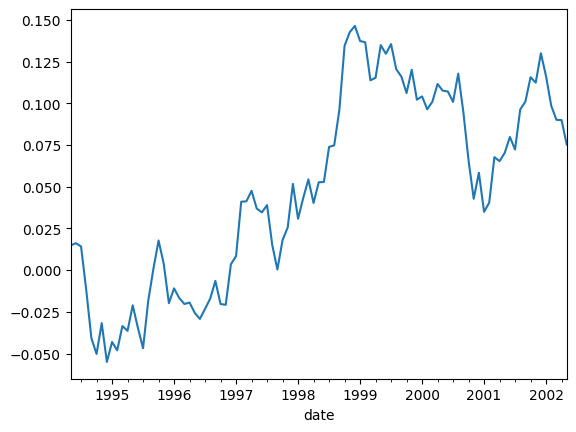

In [ ]:
p.roll_return(24).plot()

We can also plot cpi and rf to get get a better feel of returns and conditions

<Axes: xlabel='date'>

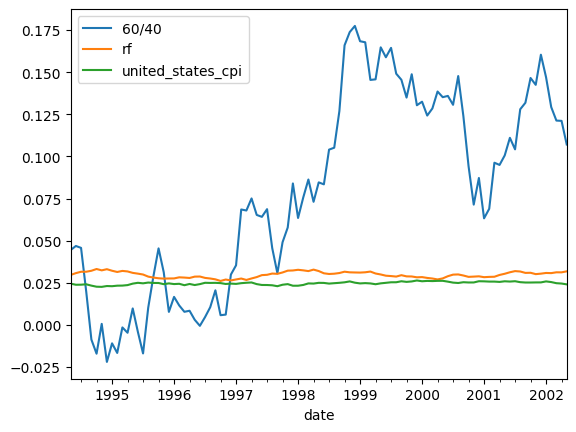

In [ ]:
p.roll_return(24, excess=False, extras=True).plot()

We can also do a rolling return inflation adjusted. How much purchasing power we would gain/lose over a period of time. Annualised.

In [ ]:
#| export
@patch
def versus_cpi(self:Portfolio, months=12):
    'Rolling real return (linearly summed). Shows you how much real purchasing power you would have lost/gained at any point in time'
    years = months/12
    r = (self._port_rets(excess=False) - self.cpi).dropna()
    r = r.rolling(months).sum().dropna()
    return r/years

<Axes: xlabel='date'>

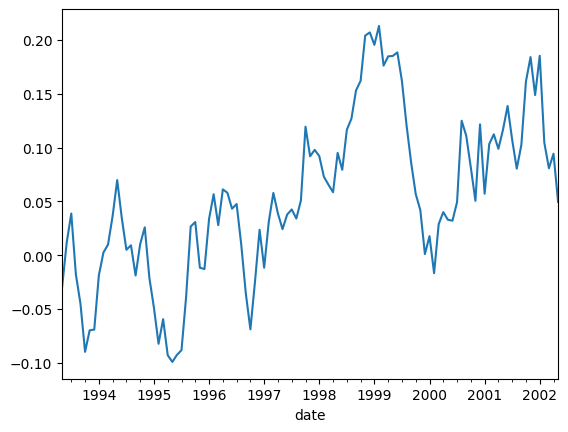

In [ ]:
p.versus_cpi().plot()

Cumulative Excess Return. Shows how portfolio performs each month, upwards sloping means we are doing better than risk-free, downward sloping means we are doing worse. Flat means we are same as excess. Does not use compounding.

In [ ]:
#| export
@patch
def cum_excess_return(self:Portfolio):
    "Cumulative sum of monthly returns (no compounding)"
    return self.port_rets.cumsum()

<Axes: xlabel='date'>

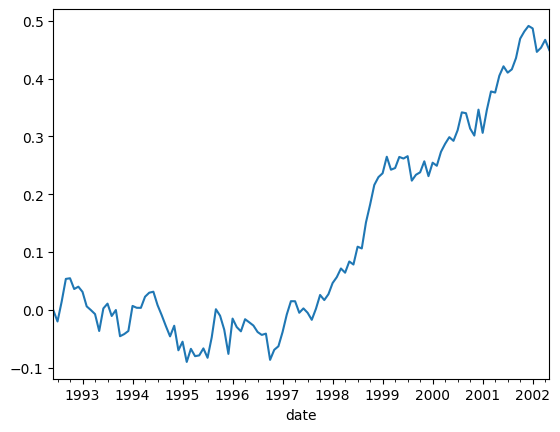

In [ ]:
p.cum_excess_return().plot()

Detrended Cumulative Return

By subtracting the long-run average monthly return (μ) before cumulating, we remove the expected drift and are left with only the unexpected component — the wiggles. This makes it much easier to see environmental biases: periods where an asset consistently outperformed or underperformed its own long-run average.

In [ ]:
#| export
@patch
def detrended_cum_return(self:Portfolio):
    "Cumulative sum of returns minus long-run mean — removes drift, shows environmental cycles"
    r = self.port_rets
    return (r - r.mean()).cumsum()

<Axes: xlabel='date'>

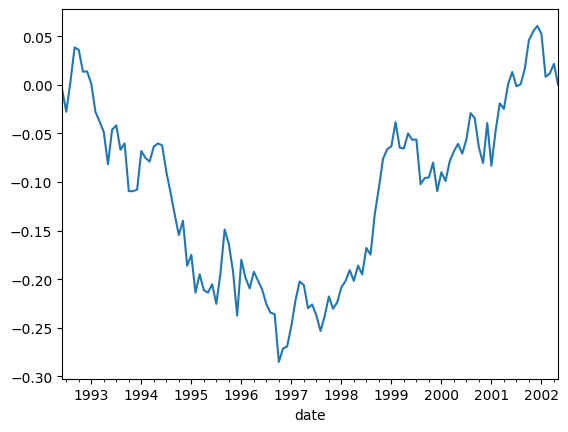

In [ ]:
p.detrended_cum_return().plot()

## Comparing portfolios

In [ ]:
p1 = Portfolio("60/40", rets, weights={'stocks': 0.60, 'bonds': 0.40}, rf=rf)
p2 = Portfolio("Risk Parity", rets, weights={'stocks': 0.42, 'bonds': 0.58}, rf=rf)

If we have two or more portfolios we should be able to easily compare metrics

In [ ]:
#| export
def compare(*portfolios, metric='stats', **kwargs):
    df = pd.concat([getattr(p, metric)(**kwargs) for p in portfolios], axis=1)
    df.name = metric
    return df

In [ ]:
compare(p1,p2)

,60/40,Risk Parity
expected_return,0.044934,0.042318
volatility,0.077412,0.062153
sharpe_ratio,0.580450,0.680861


We may choose any of the above defined metrics or methods.

In [ ]:
compare(p1,p2, metric='cum_return').tail(2)

,60/40,Risk Parity
date,,
2002-04-01,2.077665,2.037888
2002-05-01,2.048567,2.016949


Arguments to metrics are passed in last as keyword args.

In [ ]:
compare(p1,p2, metric='roll_return', months=24).tail(2)

,60/40,Risk Parity
date,,
2002-04-01,0.089911,0.070744
2002-05-01,0.075280,0.055403


## Portfolio inspection (asset level contribution)

Statistics for each asset that makes up the portfolio. These shows the actual weighted returns as given by portfolio construction.

In [ ]:
#| export
@patch(as_prop=True)
def asset_rets(self:Portfolio):
    return (self.return_streams*self.weights)[self.weights.keys()]

In [ ]:
#| export
@patch
def asset_stats(self:Portfolio):
    'Basic portfolio (annualised) stats: exp return, vol and sharpe ratio'
    e,v,s = sharpe(self.asset_rets)
    stats = {'expected_return': e, 'volatility': v, 'sharpe_ratio': s}
    return pd.DataFrame(stats).T

In [ ]:
p.asset_stats()

,bonds,stocks
expected_return,0.014485,0.030449
volatility,0.025863,0.074921
sharpe_ratio,0.560084,0.406408


Risk Contribution

Risk contribution breaks portfolio volatility into per-asset components. Each asset's contribution is accounting for both weight and how much each asset co-moves with the total portfolio. These sum exactly to σ_p, unlike a simple weighted sum of individual vols which ignores diversification.

If a large percentage comes from a single asset it means that this asset is dominating the volatiltiy and hence risk/return profile of the portfolio.

In [ ]:
#| export
@patch
def risk_contribution(self:Portfolio):
    "Per-asset risk contribution as % of portfolio variance (sums to 1)"
    cov = self.asset_rets.join(self.port_rets).cov() * 12
    pv = cov.loc[self.name, self.name]
    rc = {a: cov.loc[a, self.name] / pv for a in self.weights}
    return pd.Series(rc, name=self.name)

In [ ]:
p.risk_contribution()

bonds     0.087468
stocks    0.912532
Name: 60/40, dtype: float64

Correlation

In [ ]:
#| export
@patch
def correlation(self:Portfolio):
    "Pairwise correlation matrix of underlying assets and portfolio"
    return self.asset_rets.join(self.port_rets).corr()

In [ ]:
p.correlation()

,bonds,stocks,60/40
bonds,1.000000,-0.074685,0.261810
stocks,-0.074685,1.000000,0.942871
60/40,0.261810,0.942871,1.000000


Driver of portfolio returns and volatility plot

In [ ]:
#| export
@patch
def return_drivers(self:Portfolio):
    "Calculates portfolio and asset rolling 1 year tot.returns"
    return self.asset_rets.join(self.port_rets).rolling(12).agg(sum)

## Drawdowns

A drawdown at time t is the percentage decline from the portfolio's previous peak to its current value. Max drawdown is the worst peak-to-trough decline over the full history — a key measure of downside risk that Sharpe ratio alone misses entirely.

In [ ]:
#| export
@patch
def drawdown_series(self:Portfolio):
    "Time series of drawdowns from rolling peak"
    wealth = self.cum_return()
    return wealth / wealth.cummax() - 1

<Axes: xlabel='date'>

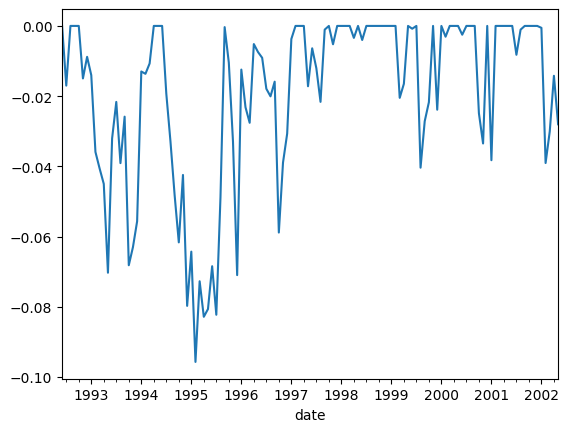

In [ ]:
p.drawdown_series().plot()

In [ ]:
#| export
@patch
def max_drawdown(self:Portfolio):
    "Worst peak-to-trough decline over full history"
    return self.drawdown_series().min().item()

In [ ]:
p.max_drawdown()

-0.09568256555766386

## Leverage

Creating a leveraged portfolio is easy. Simply specify weights that add up to more than 100%

In [ ]:
p_l = Portfolio("Leveraged", rets, weights={'stocks': 0.65, 'bonds': 0.65}, rf=rf)
p_l

{'stocks': 0.65, 'bonds': 0.65}

In [ ]:
p_u = Portfolio("Unlevered", rets, weights={'stocks': 0.50, 'bonds': 0.50}, rf=rf)
p_u

{'stocks': 0.5, 'bonds': 0.5}

Leveraging increases the volatility and return linearly. We are moving out on the risk curve.

In [ ]:
compare(p_l, p_u)

,Leveraged,Unlevered
expected_return,0.056525,0.043480
volatility,0.088569,0.068130
sharpe_ratio,0.638199,0.638199


As a result we also get larger swings and drawdowns

<Axes: xlabel='date'>

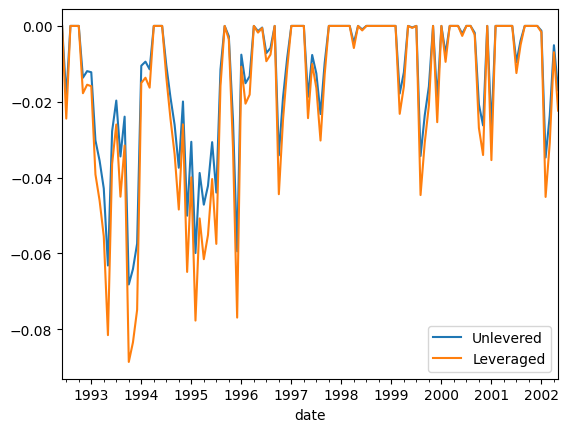

In [ ]:
compare(p_u, p_l, metric='drawdown_series').plot()

<Axes: xlabel='date'>

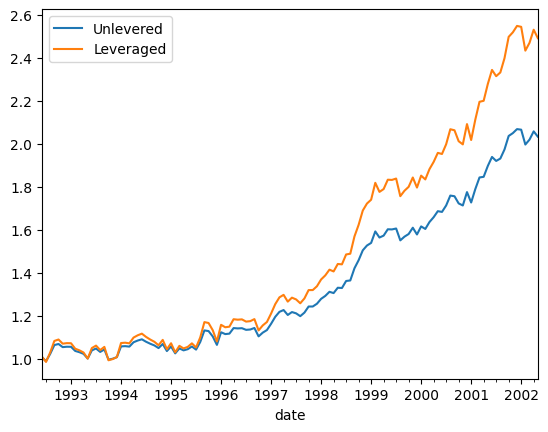

In [ ]:
compare(p_u, p_l, metric='cum_return').plot()

## Risk Parity Weighing

In [ ]:
import numpy as np
from scipy.optimize import minimize

In [ ]:
def risk_parity_weights(rets, risk_shares):
    "Compute weights given asset returns df and dict of desired risk shares"
    assets = list(risk_shares.keys())
    C = rets[assets].cov().values * 12
    r = np.array([risk_shares[a] for a in assets])
    n = len(assets)
    def obj(w): return 0.5*(w@C@w) - sum(r[i]*np.log(w[i]) for i in range(n))
    def grad(w): return C@w - r/w
    w0 = np.ones(n)/n
    bounds = [(1e-6, None)]*n
    res = minimize(obj, w0, jac=grad, method='L-BFGS-B', bounds=bounds)
    w = res.x / res.x.sum()
    return dict(zip(assets, w))

In [ ]:
risk_shares = dict(bonds=0.50, stocks=0.50)
w = risk_parity_weights(p.return_streams, risk_shares)
allw = Portfolio('allw', p.return_streams, w)
allw.risk_contribution()

bonds     0.499994
stocks    0.500006
Name: allw, dtype: float64

## Risk

Annualised per-asset vols computed over a trailing window. Useful on its own to see how each asset's risk has shifted through time.

In [ ]:
#| export
@patch
def rolling_vol(self:Portfolio, months=24):
    "Annualised rolling vol per asset over `months` window"
    return self._port_rets(excess=False, agg=False).rolling(months).agg(lambda x: x.std() * 12**0.5).dropna()

<Axes: xlabel='date'>

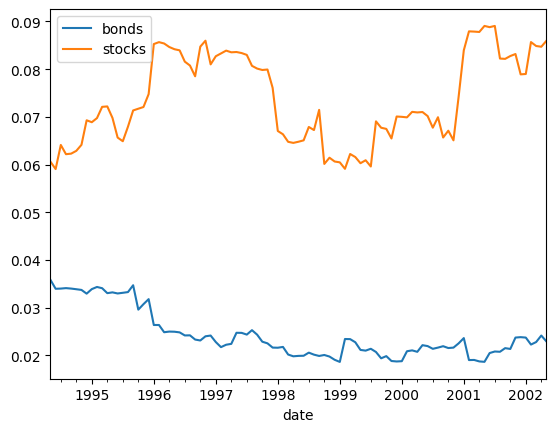

In [ ]:
p.rolling_vol().plot()

We can normalize these volatilities to get a simple measure of risk contribution. This ignores covariance and treats each asset as independent, assuming portfolio vol is simply sum of individual asset vols.

In [ ]:
#| export
@patch
def rc_simple(self:Portfolio):
    vol = self.rolling_vol()
    tot = vol.sum(axis=1)
    rc = vol.div(tot, axis=0)
    return rc

In [ ]:
rc = p.rc_simple()

<Axes: xlabel='date'>

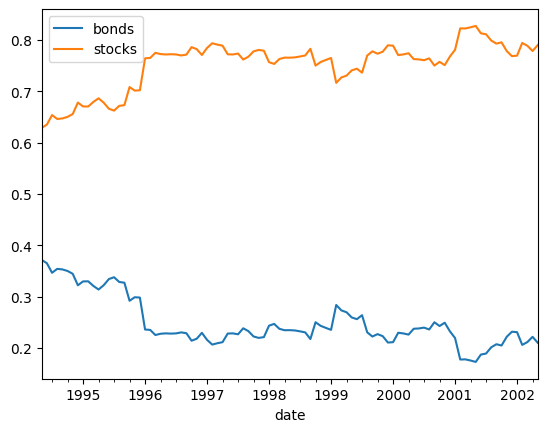

In [ ]:
rc.plot()

## Plotting Utils

Making dataframe and data series plots a bit nicer

In [ ]:
#| export
def _plot(data, log, title):
    m = np.log2(data) if log else data
    ax = m.plot(figsize=(12,6), title=title)
    if log:
        ymin,ymax = int(np.floor(m.min().min())), int(np.ceil(m.max().max()))
        ax.set_yticks(range(ymin, ymax+1))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{2.**y:.1f}x'))
    ax.grid(True, which='both', alpha=0.3)
    return ax

In [ ]:
#| export
@patch
def portfolio_plot(self:pd.DataFrame, log=False):
    title = getattr(self, 'name', ', '.join(self.columns))
    return _plot(self, log, title)

In [ ]:
#| export
@patch
def portfolio_plot(self:pd.Series, log=False):
    title = getattr(self, 'name', 'unknown')
    return _plot(self, log, title)

<Axes: title={'center': 'cum_return'}, xlabel='date'>

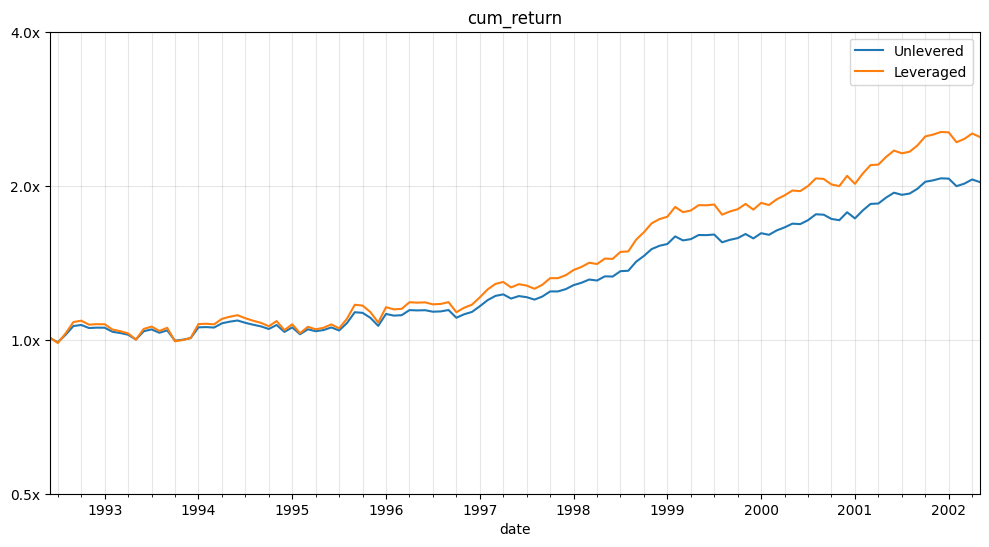

In [ ]:
compare(p_u, p_l, metric='cum_return').portfolio_plot(log=True)